# Phase 2: Feature Extraction with Pre-trained Face Models

## Goal of this notebook

Convert each face image into a fixed-length numerical "fingerprint" using a pre-trained face recognition model. We do this once, save the results, and reuse them in Phase 3 for SVR training.

## What 'pre-trained model' means here

The `deepface` library wraps several face recognition networks. We pick one (VGG-Face for our baseline, FaceNet for comparison), and we ask it to give us the high-level face representation — the second-to-last layer's output. That output is called an *embedding*. Different models produce different sized embeddings:

- VGG-Face → 4,096-dimensional embedding (matches the paper's `fc6` layer)
- FaceNet → 128- or 512-dimensional embedding (more compact, often more discriminative)

## Plan

1. Setup: mount Drive, install deepface, set up paths
2. Copy images from Drive to local Colab disk (faster I/O)
3. Load the enriched CSV from Phase 1 and filter out tiny/missing images
4. Load the pre-trained model
5. Loop through every image: extract embedding, store result
6. Save `X_train`, `X_test`, `y_train`, `y_test` to Drive
7. Sanity checks on the resulting features

## Run this notebook on a GPU runtime

Runtime → Change runtime type → T4 GPU. Feature extraction takes ~10 min on GPU vs ~2 hr on CPU.

## Cell 1: Mount Drive and install deepface

**What `deepface` is:** a Python library that wraps several face analysis models behind a single clean API. It handles model downloading, preprocessing, and inference for us. It's built on TensorFlow under the hood, but we don't have to touch TensorFlow directly — `deepface` abstracts that away.

**Why I'm using deepface instead of building from scratch with PyTorch:** for a project where you're learning frameworks for the first time, fighting framework-level details is a distraction from the actual ML problem. We want to focus on "is the BMI prediction good?" — not "how do I correctly load VGG-Face weights into PyTorch?" If you find this project interesting and want to dig deeper later, we can swap to raw PyTorch.

The `!pip install` line takes ~30 seconds. The `-q` flag means "quiet" so we don't get walls of installation text.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q deepface tf-keras

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 2: Choose your model and set up paths

**This is the cell you'll change to switch between models.** Set `MODEL_NAME` to either `'VGG-Face'` (paper baseline) or `'Facenet512'` (modern alternative). Run the rest of the notebook each time. The output filenames include the model name so the two runs don't overwrite each other.

**About `MIN_FACE_SIZE`:** I'm filtering out any image smaller than 80×80 pixels. These would be too blurry after upscaling to 224×224. We'll see how many get filtered out — if it's a tiny number (<50), this is a clean call. If it's large, we can revisit.

**Adjust the `PROJECT_ROOT` below to match your Drive folder.** From your Phase 1 screenshots, your path is `/content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final/`.

In [12]:
# --- CHANGE THIS LINE TO SWITCH MODELS ---
MODEL_NAME = 'VGG-Face'   # 'VGG-Face' (4096-dim) or 'Facenet512' (512-dim)
# -----------------------------------------

MIN_FACE_SIZE = 80   # filter out images smaller than this

# Adjust this to match your Drive structure
PROJECT_ROOT = '/content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final'
DATA_DIR = f'{PROJECT_ROOT}/Data'
DRIVE_IMAGES_DIR = f'{DATA_DIR}/Images'
ENRICHED_CSV = f'{DATA_DIR}/data_enriched.csv'

# Local Colab path for fast image reads (will be created next cell)
LOCAL_IMAGES_DIR = '/content/images'

# Output folder for features (created if it doesn't exist)
FEATURES_DIR = f'{PROJECT_ROOT}/features'

import os
os.makedirs(FEATURES_DIR, exist_ok=True)

print(f'Model:               {MODEL_NAME}')
print(f'Min face size:       {MIN_FACE_SIZE}px')
print(f'Drive images:        {DRIVE_IMAGES_DIR}')
print(f'Local images target: {LOCAL_IMAGES_DIR}')
print(f'Features output:     {FEATURES_DIR}')

Model:               VGG-Face
Min face size:       80px
Drive images:        /content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final/Data/Images
Local images target: /content/images
Features output:     /content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final/features


## Cell 3: Copy images from Drive to local Colab disk

**Why we do this:** Drivem lo is mounted over the network. Reading 3,962 images from Drive during feature extraction would mean 3,962 network round-trips, which is glacially slow. Copying everything to Colab's local SSD first means feature extraction reads frocal disk, which is dramatically faster.

**The trade-off:** local Colab disk vanishes when your session ends. So if you reconnect later, you'll need to re-run this cell. That's why we save the *features* to Drive (Cell 7), not just the images.

**`shutil.copytree` won't work directly** because it errors if the destination exists. So I use a small loop with a check. The first time you run this, it copies 3,962 files (~3-5 min). Subsequent runs skip the copy.

In [13]:
import shutil
from tqdm import tqdm

if not os.path.exists(LOCAL_IMAGES_DIR):
    os.makedirs(LOCAL_IMAGES_DIR)
    files = os.listdir(DRIVE_IMAGES_DIR)
    print(f'Copying {len(files)} files from Drive to local disk...')
    for fname in tqdm(files):
        shutil.copy(f'{DRIVE_IMAGES_DIR}/{fname}', f'{LOCAL_IMAGES_DIR}/{fname}')
    print(f'Copied. Total files now in local: {len(os.listdir(LOCAL_IMAGES_DIR))}')
else:
    print(f'Local images directory already exists with {len(os.listdir(LOCAL_IMAGES_DIR))} files. Skipping copy.')

Copying 3963 files from Drive to local disk...


100%|██████████| 3963/3963 [08:57<00:00,  7.37it/s]

Copied. Total files now in local: 3963


## Cell 4: Load and filter the metadata

We load the enriched CSV from Phase 1, then filter to:
1. Files that exist on disk (`file_exists==True`) — drops the 244 missing ones
2. Images that are at least `MIN_FACE_SIZE` in both width and height

We print before/after counts and how the train/test sizes shifted.

**Why I print these numbers:** you'll need them in your write-up. "Started with 4,206 images, removed 244 missing files and N tiny crops, ended with M images."

In [14]:
import pandas as pd

df = pd.read_csv(ENRICHED_CSV, index_col=0)
print(f'Loaded enriched CSV: {len(df)} rows')

# Filter step 1: only files that exist
before = len(df)
df = df[df['file_exists'] == True].copy()
print(f'After dropping missing files: {len(df)} rows  (-{before - len(df)})')

# Filter step 2: drop tiny images
before = len(df)
df = df[(df['width'] >= MIN_FACE_SIZE) & (df['height'] >= MIN_FACE_SIZE)].copy()
print(f'After dropping tiny images:    {len(df)} rows  (-{before - len(df)})')

# Final split
print(f'\nFinal train/test counts:')
print(df['is_training'].value_counts())
print(f'\nFinal gender counts:')
print(df['gender'].value_counts())

# Reset index so we can iterate cleanly later
df = df.reset_index(drop=True)
df.head(3)

Loaded enriched CSV: 3962 rows
After dropping missing files: 3962 rows  (-0)
After dropping tiny images:    3864 rows  (-98)

Final train/test counts:
is_training
1    3123
0     741
Name: count, dtype: int64

Final gender counts:
gender
Male      2307
Female    1557
Name: count, dtype: int64


,bmi,gender,is_training,name,file_exists,width,height,mode
0,34.207396,Male,1,img_0.bmp,True,164,176,RGB
1,26.453720,Male,1,img_1.bmp,True,150,173,RGB
2,34.967561,Female,1,img_2.bmp,True,226,251,RGB


## Cell 5: Load the pre-trained model

**The first time you run this with a given model, deepface downloads the model weights** (~500MB for VGG-Face, ~90MB for FaceNet). It caches them, so subsequent runs are instant.

**What `DeepFace.build_model` returns:** a wrapped model object. We don't typically interact with it directly — instead, we call `DeepFace.represent()` later, which uses this model under the hood.

**A note on the warning messages you'll see:** deepface uses TensorFlow underneath, which is verbose about logging. You may see warnings about CUDA, oneDNN, or deprecated APIs. These are harmless — ignore them as long as the model loads.

In [15]:
from deepface import DeepFace

print(f'Loading {MODEL_NAME}... (downloads weights on first run)')
model = DeepFace.build_model(MODEL_NAME)
print(f'Loaded {MODEL_NAME} successfully.')

Loading VGG-Face... (downloads weights on first run)
Loaded VGG-Face successfully.


## Cell 6: Test feature extraction on a single image first

Before we loop through 3,946 images (which takes ~10 min), we run on ONE image to make sure the pipeline works. If something is broken, we want to know now, not 8 minutes into a long loop.

**`DeepFace.represent()` parameters explained:**
- `img_path`: path to the image file
- `model_name`: which model to use
- `enforce_detection=False`: deepface tries to *detect* a face in the image first by default. Our images are *already* face crops, so we skip that detection step. Without `enforce_detection=False`, deepface would raise an error on images where its detector doesn't find a face — which happens occasionally even on real face crops.
- `detector_backend='skip'`: same idea, tells deepface "no face detection needed, just process the whole image as a face"

**The output structure:** `represent` returns a list of dicts (one per detected face). We grab `[0]['embedding']` to get the actual feature vector.

In [16]:
import numpy as np

# Try on the first image
sample_path = f'{LOCAL_IMAGES_DIR}/{df.iloc[0]["name"]}'
result = DeepFace.represent(
    img_path=sample_path,
    model_name=MODEL_NAME,
    enforce_detection=False,
    detector_backend='skip',
)
embedding = np.array(result[0]['embedding'])

print(f'Image: {df.iloc[0]["name"]}')
print(f'BMI:   {df.iloc[0]["bmi"]:.2f}')
print(f'Embedding shape:    {embedding.shape}')
print(f'Embedding dtype:    {embedding.dtype}')
print(f'Embedding min/max:  {embedding.min():.3f} / {embedding.max():.3f}')
print(f'Embedding mean/std: {embedding.mean():.3f} / {embedding.std():.3f}')
print(f'\nFirst 10 values:    {embedding[:10]}')

Image: img_0.bmp
BMI:   34.21
Embedding shape:    (4096,)
Embedding dtype:    float64
Embedding min/max:  0.000 / 0.163
Embedding mean/std: 0.004 / 0.015

First 10 values:    [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## Cell 7: Extract features for all images

**This is the slow cell.** ~10 minutes on a T4 GPU for VGG-Face on ~3,946 images. Don't kill it.

**Strategy:** loop through every row, get the embedding, append to a list. After the loop, stack everything into one big NumPy array.

**Error handling:** occasionally an image will fail (corrupt file, weird format). Instead of crashing the whole loop, we catch the error, log the filename, and append a row of zeros. We collect failed filenames so we can investigate at the end. If only a handful fail, we drop those rows. If many fail, something's systematically wrong.

**Why I save BMI labels as a separate array:** scikit-learn expects `X` (features) and `y` (target) as separate inputs. Keeping them separate from the start saves a step later.

In [17]:
embeddings = []
bmis = []
genders = []
is_training_flags = []
names = []
failed = []

for _, row in tqdm(df.iterrows(), total=len(df), desc=f'Extracting {MODEL_NAME} features'):
    img_path = f'{LOCAL_IMAGES_DIR}/{row["name"]}'
    try:
        result = DeepFace.represent(
            img_path=img_path,
            model_name=MODEL_NAME,
            enforce_detection=False,
            detector_backend='skip',
        )
        emb = np.array(result[0]['embedding'])
        embeddings.append(emb)
        bmis.append(row['bmi'])
        genders.append(row['gender'])
        is_training_flags.append(row['is_training'])
        names.append(row['name'])
    except Exception as e:
        failed.append((row['name'], str(e)[:120]))

print(f'\nSuccessfully extracted: {len(embeddings)}')
print(f'Failed:                 {len(failed)}')
if failed:
    print('\nFirst 5 failures:')
    for name, err in failed[:5]:
        print(f'  {name}: {err}')

# Stack into proper arrays
X = np.vstack(embeddings)
y = np.array(bmis)
is_train_arr = np.array(is_training_flags)
gender_arr = np.array(genders)
names_arr = np.array(names)

print(f'\nFinal X shape: {X.shape}')
print(f'Final y shape: {y.shape}')

Extracting VGG-Face features: 100%|██████████| 3864/3864 [01:43<00:00, 37.21it/s]



Successfully extracted: 3864
Failed:                 0

Final X shape: (3864, 4096)
Final y shape: (3864,)


## Cell 8: Split into train/test and save to Drive

We use the `is_training` flag from the original CSV (not a random split). This preserves the paper's split so our results are comparable.

**File naming:** I include `MODEL_NAME` in the filename so VGG-Face features and FaceNet features don't overwrite each other.

**`np.save` writes a `.npy` file**, which is NumPy's native format — fast to read back and preserves the array shape exactly.

In [18]:
train_mask = is_train_arr == 1
test_mask  = is_train_arr == 0

X_train = X[train_mask]
X_test  = X[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]
gender_train = gender_arr[train_mask]
gender_test  = gender_arr[test_mask]
names_train  = names_arr[train_mask]
names_test   = names_arr[test_mask]

print(f'Train: X {X_train.shape}, y {y_train.shape}')
print(f'Test:  X {X_test.shape}, y {y_test.shape}')

# Save everything
tag = MODEL_NAME.replace('-', '_')   # 'VGG-Face' -> 'VGG_Face' (cleaner filename)

np.save(f'{FEATURES_DIR}/X_train_{tag}.npy', X_train)
np.save(f'{FEATURES_DIR}/X_test_{tag}.npy',  X_test)
np.save(f'{FEATURES_DIR}/y_train_{tag}.npy', y_train)
np.save(f'{FEATURES_DIR}/y_test_{tag}.npy',  y_test)
np.save(f'{FEATURES_DIR}/gender_train_{tag}.npy', gender_train)
np.save(f'{FEATURES_DIR}/gender_test_{tag}.npy',  gender_test)
np.save(f'{FEATURES_DIR}/names_train_{tag}.npy', names_train)
np.save(f'{FEATURES_DIR}/names_test_{tag}.npy',  names_test)

print(f'\nSaved all arrays to: {FEATURES_DIR}')

Train: X (3123, 4096), y (3123,)
Test:  X (741, 4096), y (741,)

Saved all arrays to: /content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final/features


## Cell 9: Sanity checks on the extracted features

Two quick checks to confirm features are reasonable before we hand them to Phase 3:

**Check 1: Feature value distribution.** Healthy embeddings have a roughly normal-ish distribution of values, no all-zeros, no exploding magnitudes. We plot a histogram of all values.

**Check 2: Do similar BMIs produce similar embeddings?** This is the crucial "is the signal there" test. We pick a random anchor image, compute the cosine similarity between its embedding and every other image's embedding, then check if the top-most-similar embeddings tend to have BMIs close to the anchor's BMI. If yes, our SVR has a real chance. If totally random, the features aren't capturing BMI-relevant signal.

**About cosine similarity:** when you have two vectors, cosine similarity measures the angle between them, ignoring their magnitudes. Values range from -1 (opposite) to 1 (identical direction). For face embeddings, similar faces produce vectors pointing in similar directions, hence high cosine similarity.

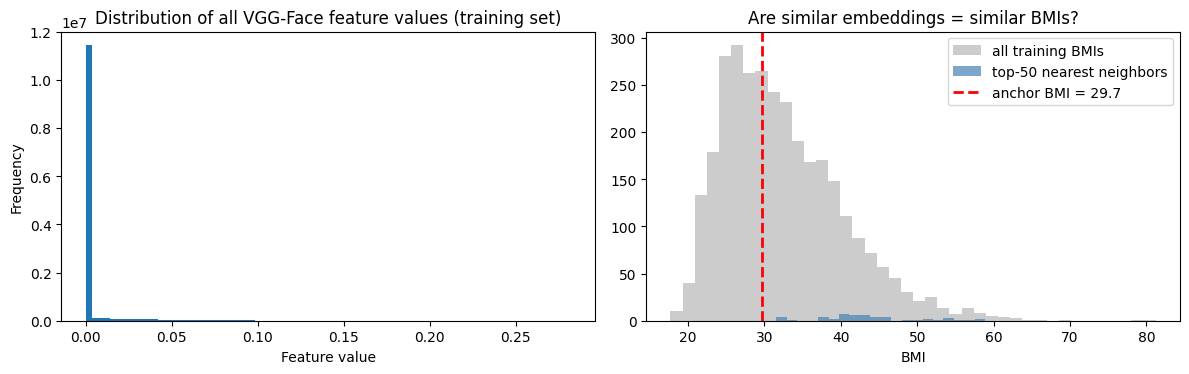

Anchor BMI:                   29.7
Mean BMI of all training:     32.4
Mean BMI of top-50 neighbors: 43.8

If neighbors' mean is closer to anchor BMI than overall mean,
the features are capturing BMI-relevant signal.


In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Check 1: distribution of feature values
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(X_train.flatten(), bins=80)
ax[0].set_title(f'Distribution of all {MODEL_NAME} feature values (training set)')
ax[0].set_xlabel('Feature value')
ax[0].set_ylabel('Frequency')

# Check 2: similar embeddings -> similar BMIs?
# Pick an anchor image from the test set
anchor_idx = 0
anchor_emb = X_test[anchor_idx:anchor_idx+1]
anchor_bmi = y_test[anchor_idx]

# Cosine similarity between anchor and all training embeddings
sims = cosine_similarity(anchor_emb, X_train)[0]

# Sort by similarity, look at top-50 nearest neighbors' BMIs
top_k = 50
top_indices = sims.argsort()[-top_k:][::-1]
neighbor_bmis = y_train[top_indices]

ax[1].hist(y_train, bins=40, alpha=0.4, label='all training BMIs', color='gray')
ax[1].hist(neighbor_bmis, bins=20, alpha=0.7, label=f'top-{top_k} nearest neighbors', color='steelblue')
ax[1].axvline(anchor_bmi, color='red', linestyle='--', linewidth=2, label=f'anchor BMI = {anchor_bmi:.1f}')
ax[1].set_title('Are similar embeddings = similar BMIs?')
ax[1].set_xlabel('BMI')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f'Anchor BMI:                   {anchor_bmi:.1f}')
print(f'Mean BMI of all training:     {y_train.mean():.1f}')
print(f'Mean BMI of top-{top_k} neighbors: {neighbor_bmis.mean():.1f}')
print(f'\nIf neighbors\' mean is closer to anchor BMI than overall mean,')
print(f'the features are capturing BMI-relevant signal.')

## What you should see when this notebook finishes

- Feature shapes printed: `X_train (~3210, 4096)` for VGG-Face or `(~3210, 512)` for Facenet512
- A histogram of feature values that's roughly bell-shaped (not all zeros, not exploding)
- The 'top neighbors' histogram concentrated near the anchor BMI line (suggests features have BMI signal)
- Files saved to your Drive `features/` folder

## What can go wrong

- **'No module named deepface'** → the pip install in Cell 1 failed. Re-run it.
- **Out-of-memory errors during extraction** → switch to a high-RAM runtime, or process in batches (we can adjust if this happens).
- **Many failed images** → tells me one of two things: bad files (we'd inspect those filenames) or a deepface bug. Send me the failure list.
- **Top-neighbors histogram looks just like the overall distribution** → features aren't capturing BMI signal. This would be surprising for VGG-Face but would be a critical finding.

## To run for both models

After this finishes for VGG-Face:
1. Go to Cell 2, change `MODEL_NAME = 'Facenet512'`
2. Restart the runtime (Runtime → Restart) to clear the loaded VGG-Face model from memory
3. Run all cells again

You'll end up with both sets of features in your `features/` folder. Phase 3 will train an SVR on each set and compare.

## Next: Phase 3

Once features are saved for at least VGG-Face, ping me. Phase 3 is short — it's the SVR training and evaluation. After that we have a real number to compare to the paper's 0.65.